# A Simple Multi-AI-Agent System with LangGraph

The earlier notebooks used **one agent**: a single LLM with a set of tools that decides what to do next. That works until the job has several distinct parts, such as researching, writing, and reviewing, each needing different instructions and tools. Packing all of that into one prompt makes the agent harder to debug and more likely to pick the wrong tool.

A **multi-agent system** splits the job across several **specialised agents**, each with its own prompt and its own small set of tools. LangGraph connects them as nodes in one graph, so they share state and hand work to each other.

## Why use multiple agents?

| Single agent | Multiple agents |
|---|---|
| One long prompt covering every task | Each agent has a short, focused prompt |
| Every tool is offered on every step | Each agent only sees the tools it needs |
| Hard to tell which part went wrong | Each agent is a separate node you can trace and test |

## Core building blocks

| Concept | What it is | In LangGraph |
|---|---|---|
| **Agent** | An LLM with its own system prompt (and optionally its own tools) | A node function that calls the LLM with that prompt |
| **Shared state** | The data every agent reads from and writes to | A `State` `TypedDict`, usually with `messages: Annotated[list, add_messages]` |
| **Handoff** | Passing control from one agent to the next | A fixed `add_edge`, a conditional edge, or `Command(goto="agent_name")` |
| **Supervisor** (optional) | A coordinating agent that decides which agent works next | An LLM node whose routing function returns the next node's name (a `Literal`) |

## Two simple patterns

**1. Sequential pipeline:** agents run in a fixed order, each building on the previous agent's output.

```
START ──▶ researcher ──▶ writer ──▶ END
```

**2. Supervisor:** one agent routes the work, and each specialist reports back to it until the job is done.

```
START ──▶ supervisor ──▶ END
              │
              ├──▶ researcher ──▶ back to supervisor
              └──▶ writer     ──▶ back to supervisor
```

## Steps

1. **Define the shared state**: the `messages` list with the `add_messages` reducer, plus any extra fields the agents need (for example, `next` for routing).
2. **Create the LLM** and give each agent its own **system prompt**, and its own tools if it needs any.
3. **Write one node per agent**: it reads the state, calls the LLM with its prompt, and returns its reply under the **`messages`** key.
4. **Connect the agents**: fixed edges for a pipeline, or a routing function with `add_conditional_edges` for a supervisor.
5. **Compile and visualise**: `graph.get_graph().draw_mermaid_png()`.
6. **Run it and trace it in LangSmith** to see which agent did what, and in what order.

## Things to watch

- **Label each agent's output.** All agents write to the same message history, so set `name="researcher"` (or similar) on each reply. Then the next agent, and you, can tell who said what.
- **Every agent is another LLM call.** More agents means more cost and latency. Split the work only when each agent clearly does its part better on its own.
- **Supervisors can loop.** If the supervisor keeps sending work back and forth, cap the run with `config={"recursion_limit": N}`.


In [1]:
import os
from typing import TypedDict, Annotated, List, Dict, Any, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langgraph.prebuilt import create_react_agent, ToolNode, tools_condition
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
print("Import Successful")

Import Successful


In [2]:
try:
    load_dotenv()
    print("Loaded .env file")
except Exception as e:
    print(f"Error loading .env file: {e}")

Loaded .env file


In [3]:
## State Definitions
class AgentState(MessagesState):
    """State for the agent, including messages and context."""
    next_agent:str # which agent to call next


In [4]:
@tool
def web_search(query: str) -> dict:
    """Search the web for current information using Tavily."""
    search = TavilySearch(max_results=3)
    try:
        return search.invoke({"query": query})
    except Exception as e:
        return {"error": f"Web search failed: {str(e)}"}


In [5]:
@tool
def write_summary(content: str) -> dict:
    """Write a summary of the content."""
    sumamry = f"Summary of the content: {content[:100]}..."  # Placeholder summary logic
    return {"summary": sumamry}

In [6]:
## groq model

def create_openai_model(model: str = "gpt-5", temperature: float = 0.7) -> ChatOpenAI:
    """Create an OpenAI model with the specified parameters."""
    return ChatOpenAI(model=model, temperature=temperature)

In [7]:
## Define researcher agent
def research_agent(state:AgentState) -> dict:
    """Research agent: gathers the key facts about the user's question."""
    messages = state["messages"]

    ## Add system message to guide the agent
    system_msg = SystemMessage(content="You are a research agent. Gather the key facts, findings, and examples about the user's question. Give bullet points, not a final essay.")

    ## call llm (no tools yet; tool calling is the next assignment)
    llm = create_openai_model()
    response = llm.invoke([system_msg] + messages)

    # Return the response to route writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }


In [8]:
## define writer agent
def writer_agent(state:AgentState) -> dict:
    """Writer agent: turns the research into a clear summary."""
    messages = state["messages"]

    ## Add system message to guide the agent
    system_msg = SystemMessage(content="You are a technical writer agent. Review the conversation and turn the research into a clear, well-structured summary for the user.")

    ## call llm (no tools yet)
    llm = create_openai_model()
    response = llm.invoke([system_msg] + messages)

    # Return the response to route back to user
    return {
        "messages": [response],
        "next_agent": "end"
    }


In [9]:
## define tol executer node
def tool_executor(state:AgentState) -> StateGraph:
    """Execute the tool based on the next_agent state."""
    messages = state["messages"]
    last_message = messages[-1] if messages else None

    ## check if there are too calls to execute
    if hasatter(last_message, "tool_call") and last_message.tool_call:
        tool_node = ToolNode([web_search, write_summary])
        response = tool_node.invoke(state)
        return  response

    ## No tool call, return the state as is
    return state
        

In [10]:
## Minimal working example of a multi-agent system with a research agent and a writer agent.
def multi_agent_system():
    """Minimal multi-agent system using llm call"""

    # build graph
    workflow = StateGraph(AgentState)

    # Add nodes for researcher and writer agents
    workflow.add_node("researcher", research_agent)
    workflow.add_node("writer", writer_agent)

    ## Define flow between agents
    workflow.set_entry_point("researcher")
    workflow.add_edge("researcher", "writer")
    workflow.add_edge("writer", END)

    print("Compiled workflow successfully")
    return workflow.compile()


Compiled workflow successfully


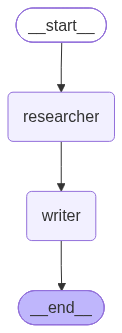

In [11]:
graph = multi_agent_system()
graph

In [12]:
## Call the multi-agent system with a message
result = graph.invoke(
    {"messages": [HumanMessage(content="What is the latest research on AI guardrails?")]}
)

## Show the full conversation: your question, the researcher's notes, the writer's summary
for message in result["messages"]:
    message.pretty_print()

print("next_agent:", result["next_agent"])


================================ Human Message =================================

What is the latest research on AI guardrails?
================================== Ai Message ==================================

Note: My knowledge is current through Oct 2024. “Latest” here reflects work and releases up to that date.

What “AI guardrails” generally means
- Policy and technical controls that constrain model behavior to meet safety, security, privacy, legal, and brand requirements.
- Layers typically include: input filtering, retrieval filtering, tool/action gating, decoding-time controls, output filtering, provenance/watermarking, monitoring, and human-in-the-loop.

Core technical approaches (with key findings)
- Alignment fine-tuning
  - RLHF (Reinforcement Learning from Human Feedback): effective but can overfit reward models and induce over-refusal.
  - RLAIF/Constitutional AI (Anthropic, 2022–2023): uses AI feedback and explicit “constitutions” to reduce harm; showed AI feedback can be